In [22]:
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import time

# Task 1:

Here I will load the dataset and only select 12 classes to train and test with.

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar100.load_data()
NUM_CLASSES = 12
SELECTED_CLASSES = list(range(NUM_CLASSES))
# Normalize pixel values to be between 0 and 1
train_images = train_images.astype("float32") / 255.0
test_images  = test_images.astype("float32") / 255.0

train_mask = np.isin(train_labels.flatten(), SELECTED_CLASSES)
x_train = train_images[train_mask]
y_train = train_labels[train_mask]

# Same filter for test set
test_mask = np.isin(test_labels.flatten(), SELECTED_CLASSES)
x_test = test_images[test_mask]
y_test = test_labels[test_mask]

d:\IDL\IDL Project\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Printing part of the dataset

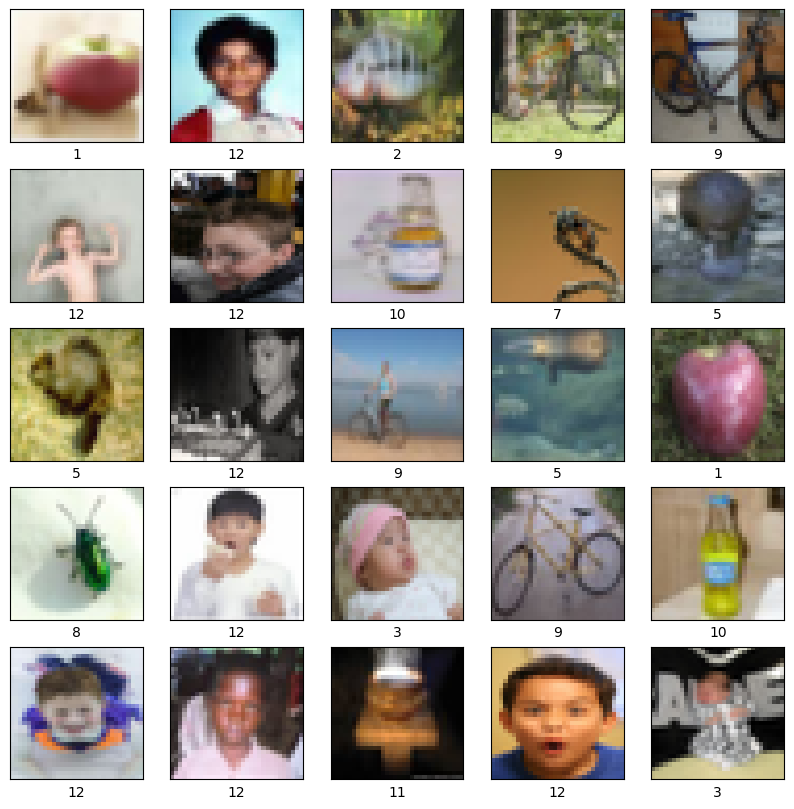

In [ ]:
class_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11','12']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i]
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

# Task 2 

Adding several  Conv layers , Maxpooling layers and inner dense layers. 

In [4]:
model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(NUM_CLASSES))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,236 (2.49 MB)

 Trainable params: 652,236 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

# Task 3:

Training the CNN model on the training set.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
    )

history = model.fit(
    x_train, y_train, epochs=20, 
    batch_size=64,
    validation_split=0.1
    )

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1656 - loss: 2.3763 - val_accuracy: 0.2850 - val_loss: 2.1226
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3085 - loss: 2.0241 - val_accuracy: 0.3717 - val_loss: 1.8452
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4091 - loss: 1.7584 - val_accuracy: 0.4333 - val_loss: 1.6509
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4711 - loss: 1.5588 - val_accuracy: 0.5183 - val_loss: 1.4419
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5259 - loss: 1.4109 - val_accuracy: 0.5450 - val_loss: 1.3938
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5763 - loss: 1.2620 - val_accuracy: 0.5817 - val_loss: 1.3393
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6150 - loss: 1.1529 - val_accuracy: 0.5900 - val_loss: 1.2973
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6519 - loss: 1.0289 - val_accuracy: 0.5633 - v

# Task 4:

Model Evaluation

38/38 - 0s - 4ms/step - accuracy: 0.6483 - loss: 1.5183


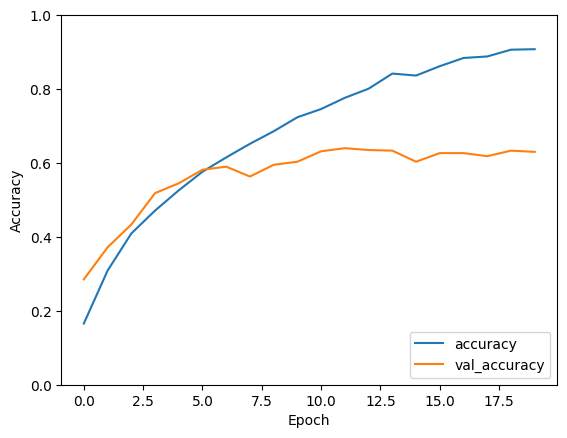

In [11]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

In [10]:
print(test_acc)

0.6483333110809326


# Task 5:

Experiments to improve the performance.

In [ ]:
def build_cnn(
    num_conv_blocks=3,
    filters=32,
    kernel_size=3,
    conv_activation="relu",
    num_dense=2,
    dense_units=256,
    dense_activation="relu",
    dropout_rate=0.3,
    input_shape=(32, 32, 3),
    num_classes=NUM_CLASSES,
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    for i in range(num_conv_blocks):
        f = filters * (2 ** i)
        model.add(layers.Conv2D(f, kernel_size, activation=conv_activation, padding="same"))
        model.add(layers.MaxPooling2D(2))
    model.add(layers.Flatten())
    for _ in range(num_dense):
        model.add(layers.Dense(dense_units, activation=dense_activation))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes))
    return model

def run_experiment(model, optimizer="adam", learning_rate=1e-3,
                   epochs=20, batch_size=64, name="exp"):
    opt_map = {
        "adam": optimizers.Adam,
        "sgd": optimizers.SGD,
        "rmsprop": optimizers.RMSprop,
        "adamw": optimizers.AdamW,
    }
    opt = opt_map[optimizer](learning_rate=learning_rate)
    model.compile(optimizer=opt,
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=["accuracy"])
    start = time.time()
    history = model.fit(x_train, y_train, validation_split=0.1,
                        epochs=epochs, batch_size=batch_size, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n[{name}] Test acc: {test_acc:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, elapsed

def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="val")
    ax1.set_title(f"Accuracy – {title}"); ax1.legend()
    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="val")
    ax2.set_title(f"Loss – {title}"); ax2.legend()
    plt.tight_layout(); plt.show()

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1750 - loss: 2.3573 - val_accuracy: 0.2883 - val_loss: 2.1476
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3257 - loss: 2.0034 - val_accuracy: 0.3817 - val_loss: 1.8456
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4241 - loss: 1.7233 - val_accuracy: 0.4750 - val_loss: 1.6049
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4822 - loss: 1.5440 - val_accuracy: 0.5150 - val_loss: 1.4887
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5350 - loss: 1.3983 - val_accuracy: 0.5150 - val_loss: 1.4400
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5728 - loss: 1.2698 - val_accuracy: 0.5400 - val_loss: 1.3977
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6063 - loss: 1.1827 - val_accuracy: 0.5783 - val_loss: 1.2684
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6446 - loss: 1.0771 - val_accuracy: 0.5567 - v

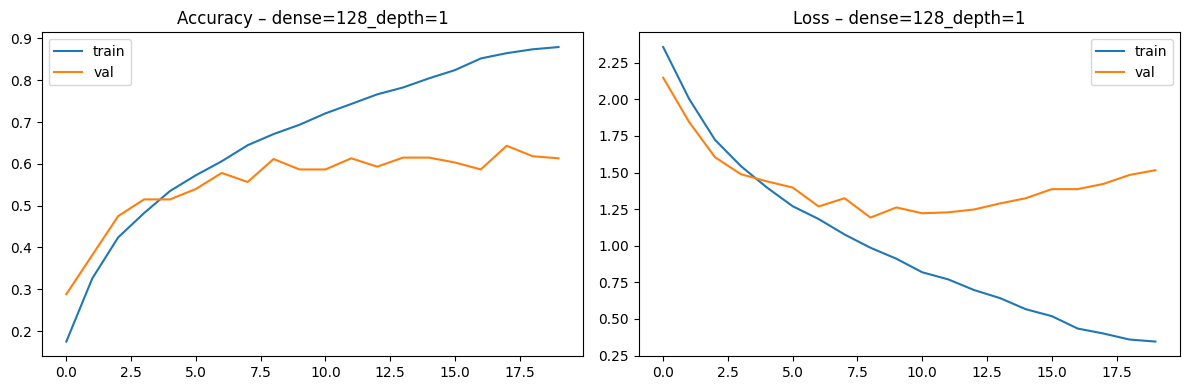

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1328 - loss: 2.4167 - val_accuracy: 0.1850 - val_loss: 2.2553
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2524 - loss: 2.1867 - val_accuracy: 0.3383 - val_loss: 1.9534
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3430 - loss: 1.9226 - val_accuracy: 0.3583 - val_loss: 1.8342
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4017 - loss: 1.7699 - val_accuracy: 0.4250 - val_loss: 1.6829
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4587 - loss: 1.6076 - val_accuracy: 0.4667 - val_loss: 1.5576
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5035 - loss: 1.4703 - val_accuracy: 0.5150 - val_loss: 1.4076
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5378 - loss: 1.3709 - val_accuracy: 0.5317 - val_loss: 1.4048
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5715 - loss: 1.2479 - val_accuracy: 0.5617 - v

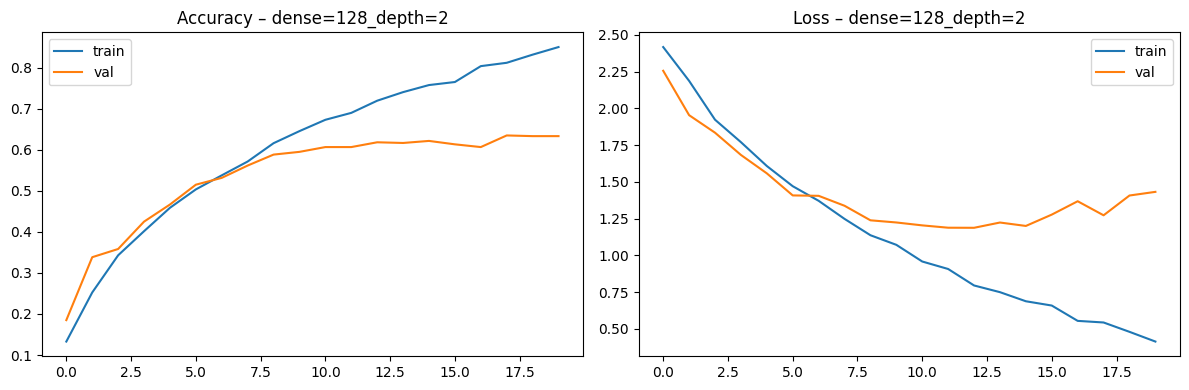

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1020 - loss: 2.4638 - val_accuracy: 0.1750 - val_loss: 2.3680
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1830 - loss: 2.3098 - val_accuracy: 0.2850 - val_loss: 2.1146
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2815 - loss: 2.0638 - val_accuracy: 0.3567 - val_loss: 1.8736
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3554 - loss: 1.8552 - val_accuracy: 0.3783 - val_loss: 1.7212
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4198 - loss: 1.6989 - val_accuracy: 0.4683 - val_loss: 1.6136
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4661 - loss: 1.5669 - val_accuracy: 0.4633 - val_loss: 1.5300
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5074 - loss: 1.4401 - val_accuracy: 0.5050 - val_loss: 1.4664
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5481 - loss: 1.3335 - val_accuracy: 0.5250 - v

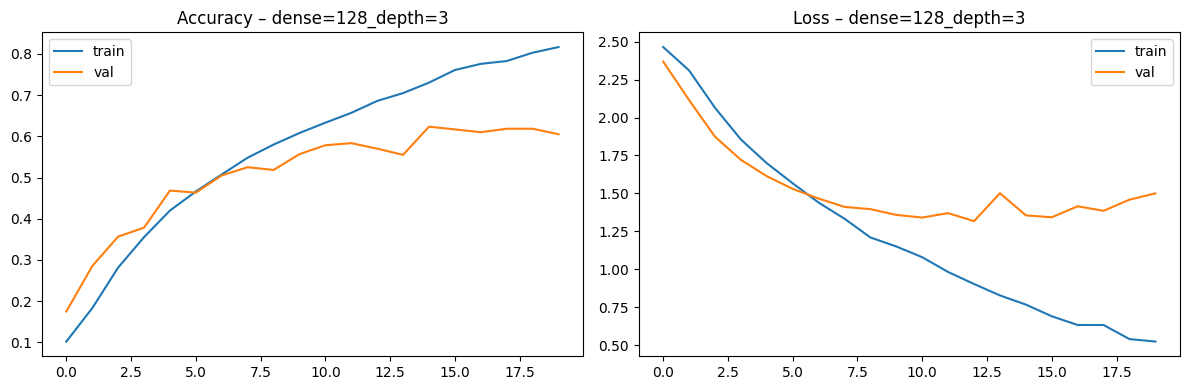

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2274 - loss: 2.2538 - val_accuracy: 0.3233 - val_loss: 1.9925
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3974 - loss: 1.8101 - val_accuracy: 0.4017 - val_loss: 1.7371
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4863 - loss: 1.5519 - val_accuracy: 0.5117 - val_loss: 1.4955
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5569 - loss: 1.3458 - val_accuracy: 0.5550 - val_loss: 1.3535
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5972 - loss: 1.2103 - val_accuracy: 0.5367 - val_loss: 1.3236
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6398 - loss: 1.0759 - val_accuracy: 0.6033 - val_loss: 1.2316
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6648 - loss: 0.9866 - val_accuracy: 0.6317 - val_loss: 1.1485
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7113 - loss: 0.8734 - val_accuracy: 0.5983 - v

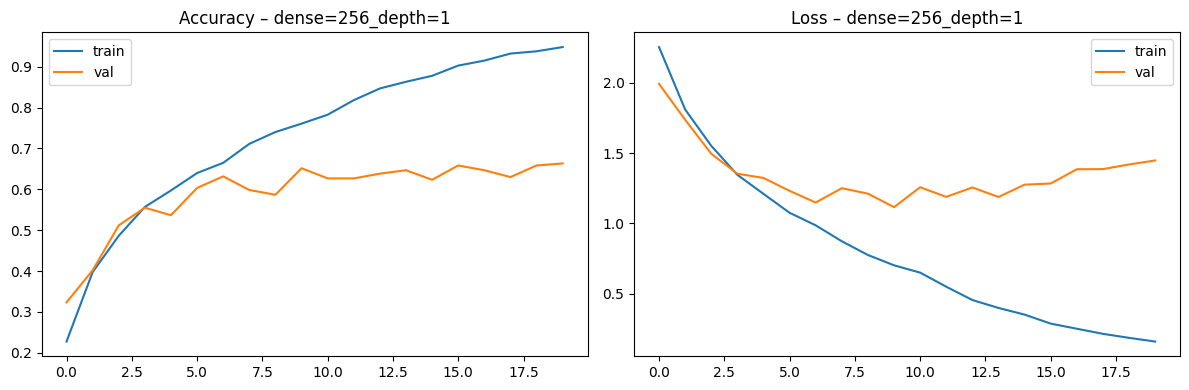

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1539 - loss: 2.3684 - val_accuracy: 0.2217 - val_loss: 2.1741
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3202 - loss: 2.0037 - val_accuracy: 0.3700 - val_loss: 1.8621
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4172 - loss: 1.7208 - val_accuracy: 0.4517 - val_loss: 1.6408
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4767 - loss: 1.5439 - val_accuracy: 0.4717 - val_loss: 1.5550
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5385 - loss: 1.3714 - val_accuracy: 0.5400 - val_loss: 1.3603
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5870 - loss: 1.2182 - val_accuracy: 0.5767 - val_loss: 1.3000
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6330 - loss: 1.0761 - val_accuracy: 0.5600 - val_loss: 1.3333
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6707 - loss: 0.9575 - val_accuracy: 0.5817 - v

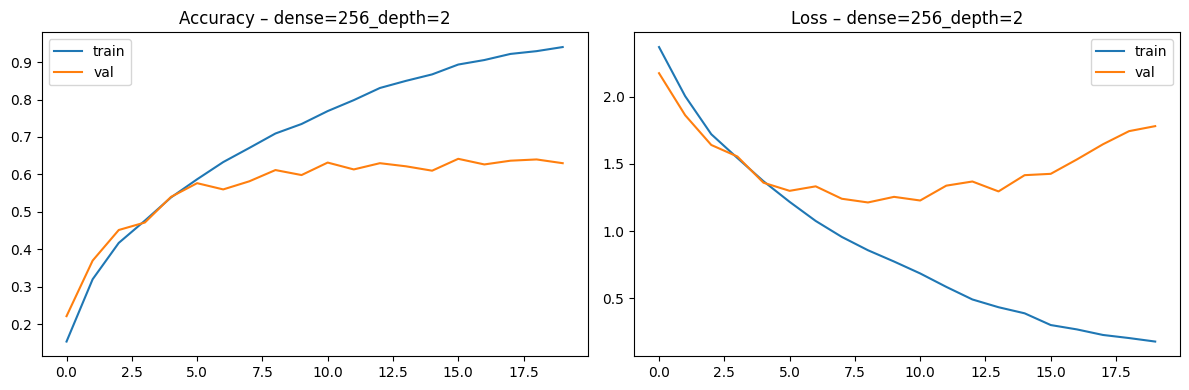

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1194 - loss: 2.4267 - val_accuracy: 0.1817 - val_loss: 2.3015
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2315 - loss: 2.1905 - val_accuracy: 0.3050 - val_loss: 2.0337
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3559 - loss: 1.8902 - val_accuracy: 0.4083 - val_loss: 1.7466
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4385 - loss: 1.6471 - val_accuracy: 0.4567 - val_loss: 1.5907
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5009 - loss: 1.4570 - val_accuracy: 0.5200 - val_loss: 1.4574
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5598 - loss: 1.3046 - val_accuracy: 0.5167 - val_loss: 1.4292
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6046 - loss: 1.1679 - val_accuracy: 0.5550 - val_loss: 1.3111
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6457 - loss: 1.0603 - val_accuracy: 0.5783 - v

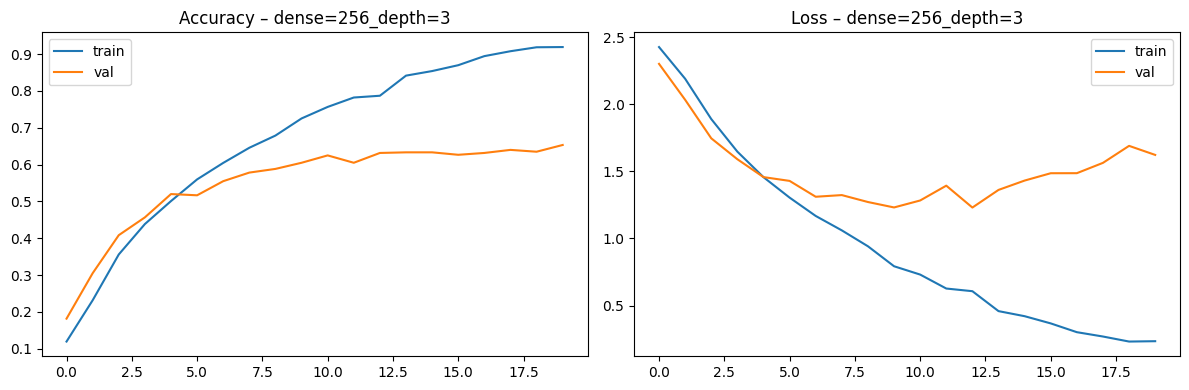

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2161 - loss: 2.2797 - val_accuracy: 0.3300 - val_loss: 1.9825
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4039 - loss: 1.8004 - val_accuracy: 0.4583 - val_loss: 1.5998
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4970 - loss: 1.5016 - val_accuracy: 0.4667 - val_loss: 1.5342
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5531 - loss: 1.3322 - val_accuracy: 0.5717 - val_loss: 1.3628
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6102 - loss: 1.1640 - val_accuracy: 0.5633 - val_loss: 1.2560
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6583 - loss: 1.0225 - val_accuracy: 0.5767 - val_loss: 1.3174
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6989 - loss: 0.9040 - val_accuracy: 0.5817 - val_loss: 1.2359
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7256 - loss: 0.8103 - val_accuracy: 0.6150 - v

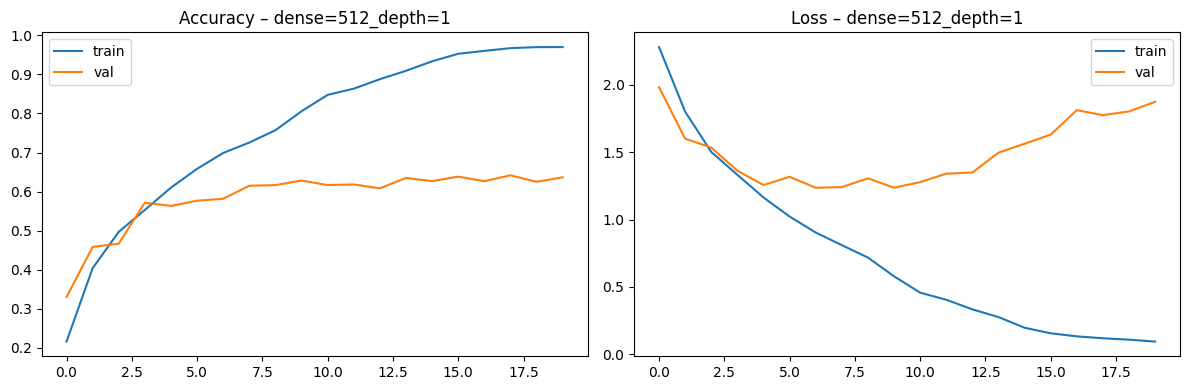

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1911 - loss: 2.2901 - val_accuracy: 0.3150 - val_loss: 1.9974
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3815 - loss: 1.8181 - val_accuracy: 0.4450 - val_loss: 1.6508
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4824 - loss: 1.5362 - val_accuracy: 0.4800 - val_loss: 1.5479
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5609 - loss: 1.3164 - val_accuracy: 0.5333 - val_loss: 1.4215
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5957 - loss: 1.2039 - val_accuracy: 0.5850 - val_loss: 1.2937
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6559 - loss: 1.0391 - val_accuracy: 0.5800 - val_loss: 1.3111
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6922 - loss: 0.9053 - val_accuracy: 0.5950 - val_loss: 1.2339
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7376 - loss: 0.7901 - val_accuracy: 0.6033 - v

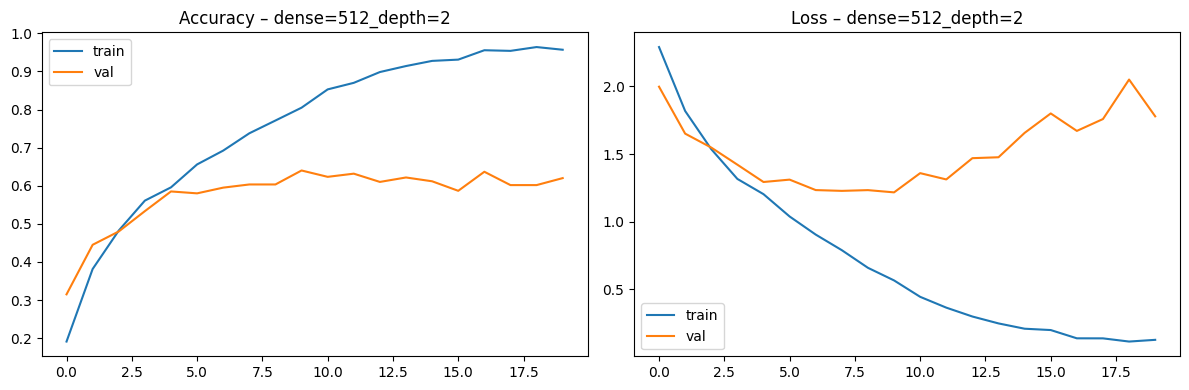

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1344 - loss: 2.4074 - val_accuracy: 0.2283 - val_loss: 2.1931
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2911 - loss: 2.0520 - val_accuracy: 0.3517 - val_loss: 1.8939
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3926 - loss: 1.7626 - val_accuracy: 0.4183 - val_loss: 1.7326
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4650 - loss: 1.5605 - val_accuracy: 0.4667 - val_loss: 1.5808
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5285 - loss: 1.3855 - val_accuracy: 0.5200 - val_loss: 1.5399
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5822 - loss: 1.2380 - val_accuracy: 0.5267 - val_loss: 1.4869
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6280 - loss: 1.0924 - val_accuracy: 0.5550 - val_loss: 1.3628
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6717 - loss: 0.9669 - val_accuracy: 0.5600 - v

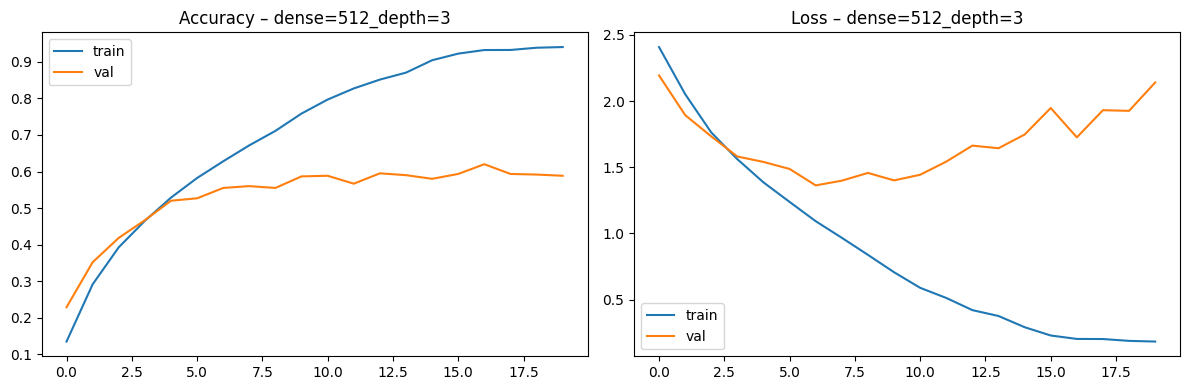


=== Experiment 5.1 Results ===
  dense=256_depth=3: 0.6725
  dense=128_depth=2: 0.6692
  dense=512_depth=2: 0.6667
  dense=256_depth=2: 0.6600
  dense=512_depth=1: 0.6567
  dense=256_depth=1: 0.6550
  dense=128_depth=1: 0.6492
  dense=128_depth=3: 0.6433
  dense=512_depth=3: 0.6242

>> Best: dense=256_depth=3 (0.6725)


In [13]:
# Baseline dense config is: dense_units=256, num_dense=2
# Try different combinations to see what improves accuracy

results_5_1 = {}
for dense_units in [128, 256, 512]:
    for num_dense in [1, 2, 3]:
        name = f"dense={dense_units}_depth={num_dense}"
        m = build_cnn(dense_units=dense_units, num_dense=num_dense)
        h, acc, _ = run_experiment(m, name=name)
        results_5_1[name] = acc
        plot_history(h, name)

print("\n=== Experiment 5.1 Results ===")
for k, v in sorted(results_5_1.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

# Pick the best and lock it in
best_5_1 = max(results_5_1, key=results_5_1.get)
print(f"\n>> Best: {best_5_1} ({results_5_1[best_5_1]:.4f})")

In [14]:
# LOCK IN best from 5.1 (update these based on YOUR results)
BEST_DENSE_UNITS = 512   # <-- replace with your winner
BEST_NUM_DENSE = 2       # <-- replace with your winner

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2302 - loss: 2.2571 - val_accuracy: 0.3517 - val_loss: 1.9441
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4072 - loss: 1.7567 - val_accuracy: 0.4733 - val_loss: 1.5950
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5226 - loss: 1.4366 - val_accuracy: 0.5233 - val_loss: 1.4178
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5959 - loss: 1.2130 - val_accuracy: 0.5867 - val_loss: 1.2909
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6526 - loss: 1.0454 - val_accuracy: 0.5867 - val_loss: 1.3050
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7100 - loss: 0.8671 - val_accuracy: 0.6017 - val_loss: 1.2616
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7591 - loss: 0.7170 - val_accuracy: 0.6083 - val_loss: 1.2774
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7967 - loss: 0.6183 - val_accuracy: 0.6000 - v

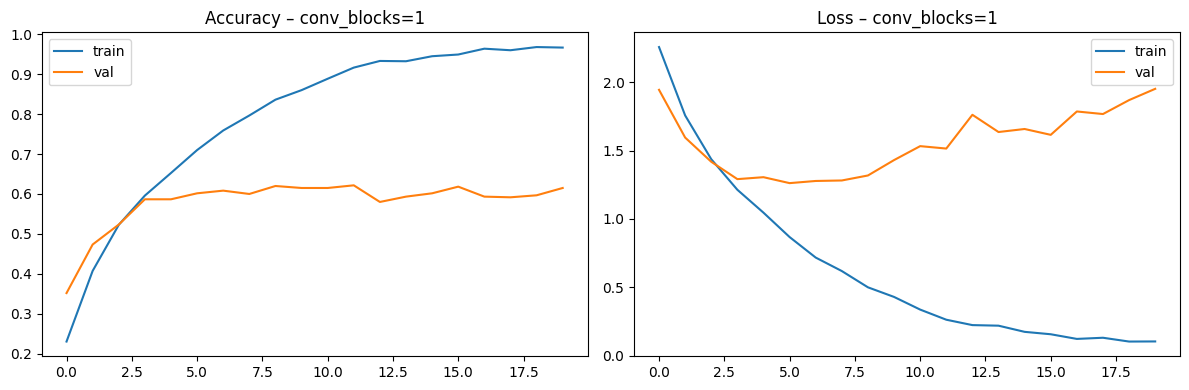

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2194 - loss: 2.2511 - val_accuracy: 0.3417 - val_loss: 1.8896
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4143 - loss: 1.7497 - val_accuracy: 0.4900 - val_loss: 1.5382
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5181 - loss: 1.4309 - val_accuracy: 0.5067 - val_loss: 1.4602
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5928 - loss: 1.2294 - val_accuracy: 0.5817 - val_loss: 1.2928
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6424 - loss: 1.0729 - val_accuracy: 0.5717 - val_loss: 1.3015
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6856 - loss: 0.9231 - val_accuracy: 0.6050 - val_loss: 1.2681
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7409 - loss: 0.7649 - val_accuracy: 0.6267 - val_loss: 1.2328
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7811 - loss: 0.6354 - val_accuracy: 0.6383 - v

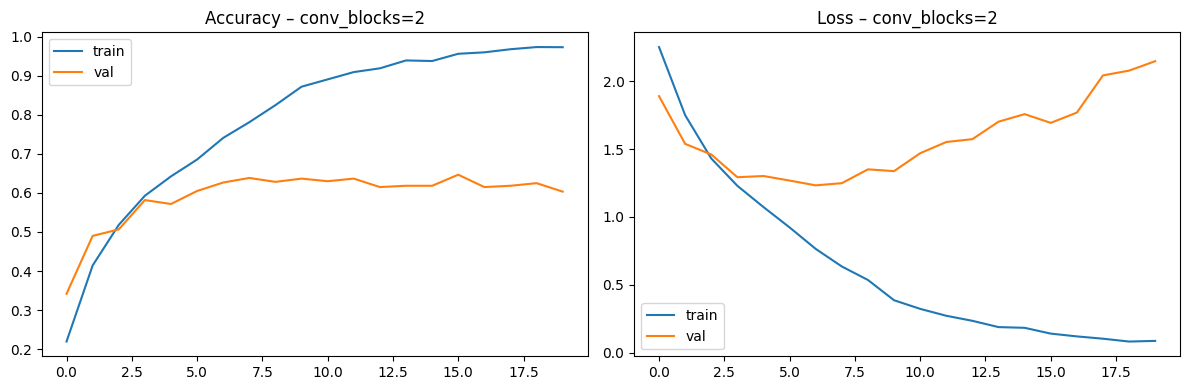

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1744 - loss: 2.3306 - val_accuracy: 0.3117 - val_loss: 2.0154
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3565 - loss: 1.9090 - val_accuracy: 0.4350 - val_loss: 1.6959
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4685 - loss: 1.5851 - val_accuracy: 0.4483 - val_loss: 1.6194
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5400 - loss: 1.3435 - val_accuracy: 0.5500 - val_loss: 1.3641
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5919 - loss: 1.1916 - val_accuracy: 0.5567 - val_loss: 1.3063
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6500 - loss: 1.0277 - val_accuracy: 0.5900 - val_loss: 1.2326
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6967 - loss: 0.8995 - val_accuracy: 0.6117 - val_loss: 1.2959
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7267 - loss: 0.7981 - val_accuracy: 0.6167 - v

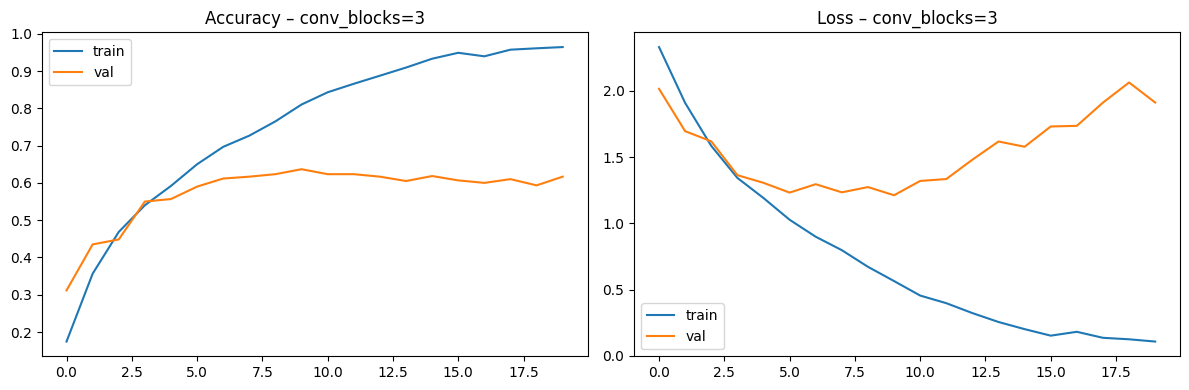

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1356 - loss: 2.4007 - val_accuracy: 0.1417 - val_loss: 2.3506
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2698 - loss: 2.1294 - val_accuracy: 0.3067 - val_loss: 1.9759
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3861 - loss: 1.7686 - val_accuracy: 0.4267 - val_loss: 1.6726
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4846 - loss: 1.5147 - val_accuracy: 0.4700 - val_loss: 1.5422
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5311 - loss: 1.3735 - val_accuracy: 0.5083 - val_loss: 1.4745
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6002 - loss: 1.1835 - val_accuracy: 0.5000 - val_loss: 1.4554
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6552 - loss: 1.0102 - val_accuracy: 0.5500 - val_loss: 1.3894
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7085 - loss: 0.8603 - val_accuracy: 0.5867 - v

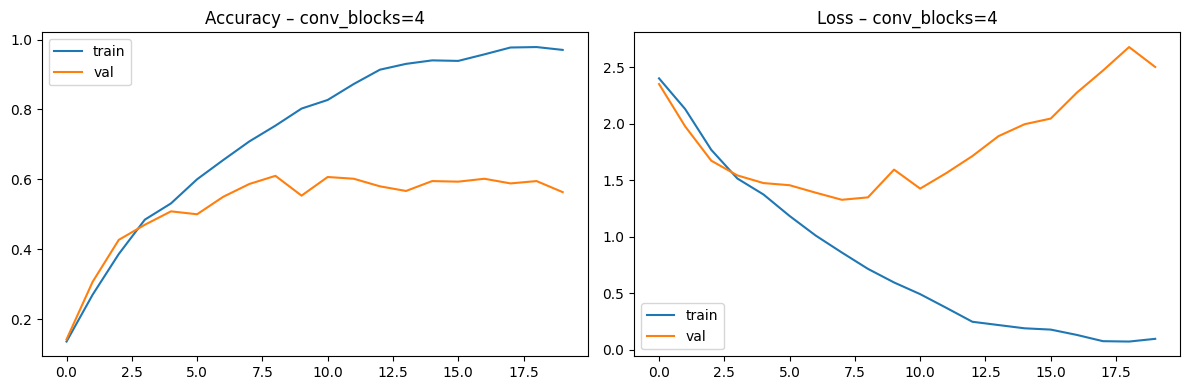


=== Experiment 5.2 Results ===
  conv_blocks=3: 0.6725
  conv_blocks=2: 0.6267
  conv_blocks=4: 0.6167
  conv_blocks=1: 0.6133

>> Best: conv_blocks=3 (0.6725)


In [15]:
results_5_2 = {}
for n_blocks in [1, 2, 3, 4]:
    name = f"conv_blocks={n_blocks}"
    m = build_cnn(num_conv_blocks=n_blocks,
                  dense_units=BEST_DENSE_UNITS,
                  num_dense=BEST_NUM_DENSE)
    h, acc, _ = run_experiment(m, name=name)
    results_5_2[name] = acc
    plot_history(h, name)

print("\n=== Experiment 5.2 Results ===")
for k, v in sorted(results_5_2.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

best_5_2 = max(results_5_2, key=results_5_2.get)
print(f"\n>> Best: {best_5_2} ({results_5_2[best_5_2]:.4f})")

In [16]:
# LOCK IN best from 5.2
BEST_CONV_BLOCKS = 3  # <-- replace with your winner

In [17]:
results_5_3 = {}
for conv_act in ["relu", "sigmoid", "tanh", "swish"]:
    for dense_act in ["relu", "sigmoid", "tanh", "swish"]:
        name = f"conv={conv_act}_dense={dense_act}"
        m = build_cnn(num_conv_blocks=BEST_CONV_BLOCKS,
                      dense_units=BEST_DENSE_UNITS,
                      num_dense=BEST_NUM_DENSE,
                      conv_activation=conv_act,
                      dense_activation=dense_act)
        h, acc, _ = run_experiment(m, epochs=15, name=name)
        results_5_3[name] = acc

print("\n=== Experiment 5.3 Results ===")
for k, v in sorted(results_5_3.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

best_5_3 = max(results_5_3, key=results_5_3.get)
print(f"\n>> Best: {best_5_3} ({results_5_3[best_5_3]:.4f})")

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1920 - loss: 2.2921 - val_accuracy: 0.2883 - val_loss: 2.0345
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3870 - loss: 1.8368 - val_accuracy: 0.4233 - val_loss: 1.6950
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4657 - loss: 1.5913 - val_accuracy: 0.4833 - val_loss: 1.5724
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5320 - loss: 1.3588 - val_accuracy: 0.5383 - val_loss: 1.3949
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5981 - loss: 1.1818 - val_accuracy: 0.5633 - val_loss: 1.2838
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6454 - loss: 1.0627 - val_accuracy: 0.5533 - val_loss: 1.3092
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6881 - loss: 0.9220 - val_accuracy: 0.6017 - val_loss: 1.2040
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7363 - loss: 0.7729 - val_accuracy: 0.6050 - v

In [18]:
# Test the winning activation with a different network size to answer that question
results_5_3b = {}
BEST_CONV_ACT = "relu"   # <-- replace with your 5.3 winner
BEST_DENSE_ACT = "relu"  # <-- replace with your 5.3 winner

for dense_units in [128, 512]:
    for num_dense in [1, 3]:
        name = f"act_combo_dense={dense_units}_depth={num_dense}"
        m = build_cnn(num_conv_blocks=BEST_CONV_BLOCKS,
                      dense_units=dense_units,
                      num_dense=num_dense,
                      conv_activation=BEST_CONV_ACT,
                      dense_activation=BEST_DENSE_ACT)
        h, acc, _ = run_experiment(m, epochs=15, name=name)
        results_5_3b[name] = acc

print("\n=== Activation + Size Combo Results ===")
for k, v in sorted(results_5_3b.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1841 - loss: 2.3133 - val_accuracy: 0.3300 - val_loss: 1.9990
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3404 - loss: 1.9452 - val_accuracy: 0.4050 - val_loss: 1.8063
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4267 - loss: 1.7022 - val_accuracy: 0.4633 - val_loss: 1.5976
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4831 - loss: 1.5500 - val_accuracy: 0.5250 - val_loss: 1.4287
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5274 - loss: 1.4233 - val_accuracy: 0.5083 - val_loss: 1.4813
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5620 - loss: 1.3110 - val_accuracy: 0.5483 - val_loss: 1.3434
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5983 - loss: 1.1956 - val_accuracy: 0.6117 - val_loss: 1.2610
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6246 - loss: 1.1359 - val_accuracy: 0.5967 - v

In [19]:
# LOCK IN best activations from 5.3
BEST_CONV_ACT = "relu"    # <-- replace
BEST_DENSE_ACT = "relu"   # <-- replace

In [20]:
results_5_4 = {}
for opt_name in ["adam", "sgd", "rmsprop", "adamw"]:
    for lr in [1e-2, 1e-3, 1e-4]:
        name = f"{opt_name}_lr={lr}"
        m = build_cnn(num_conv_blocks=BEST_CONV_BLOCKS,
                      dense_units=BEST_DENSE_UNITS,
                      num_dense=BEST_NUM_DENSE,
                      conv_activation=BEST_CONV_ACT,
                      dense_activation=BEST_DENSE_ACT)
        h, acc, _ = run_experiment(m, optimizer=opt_name,
                                   learning_rate=lr, name=name)
        results_5_4[name] = acc

print("\n=== Experiment 5.4 Results ===")
for k, v in sorted(results_5_4.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

best_5_4 = max(results_5_4, key=results_5_4.get)
print(f"\n>> Best: {best_5_4} ({results_5_4[best_5_4]:.4f})")

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0798 - loss: 2.6758 - val_accuracy: 0.0933 - val_loss: 2.4843
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0809 - loss: 2.4867 - val_accuracy: 0.0583 - val_loss: 2.4868
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0831 - loss: 2.4861 - val_accuracy: 0.0717 - val_loss: 2.4880
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0770 - loss: 2.4864 - val_accuracy: 0.0717 - val_loss: 2.4869
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0770 - loss: 2.4863 - val_accuracy: 0.0717 - val_loss: 2.4860
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0772 - loss: 2.4861 - val_accuracy: 0.0717 - val_loss: 2.4875
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0839 - loss: 2.4860 - val_accuracy: 0.0783 - val_loss: 2.4862
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0794 - loss: 2.4862 - val_accuracy: 0.0817 - v

In [23]:
# LOCK IN best optimizer settings
BEST_OPTIMIZER = "adam"  # <-- replace
BEST_LR = 1e-3          # <-- replace

In [24]:
results_5_5 = {}
for bs in [32, 64, 128, 256]:
    for ep in [10, 20, 40]:
        name = f"batch={bs}_epochs={ep}"
        m = build_cnn(num_conv_blocks=BEST_CONV_BLOCKS,
                      dense_units=BEST_DENSE_UNITS,
                      num_dense=BEST_NUM_DENSE,
                      conv_activation=BEST_CONV_ACT,
                      dense_activation=BEST_DENSE_ACT)
        h, acc, _ = run_experiment(m, optimizer=BEST_OPTIMIZER,
                                   learning_rate=BEST_LR,
                                   batch_size=bs, epochs=ep, name=name)
        results_5_5[name] = acc

print("\n=== Experiment 5.5 Results ===")
for k, v in sorted(results_5_5.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")

best_5_5 = max(results_5_5, key=results_5_5.get)
print(f"\n>> Best: {best_5_5} ({results_5_5[best_5_5]:.4f})")

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2139 - loss: 2.2559 - val_accuracy: 0.3900 - val_loss: 1.8673
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4224 - loss: 1.7040 - val_accuracy: 0.4950 - val_loss: 1.5283
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5217 - loss: 1.4165 - val_accuracy: 0.5433 - val_loss: 1.3689
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5891 - loss: 1.2217 - val_accuracy: 0.5600 - val_loss: 1.3072
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6396 - loss: 1.0729 - val_accuracy: 0.5917 - val_loss: 1.2305
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6935 - loss: 0.9042 - val_accuracy: 0.6183 - val_loss: 1.1897
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7415 - loss: 0.7436 - val_accuracy: 0.6367 - val_loss: 1.1884
Epoch 8/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7833 - loss: 0.6315 - val_accu

In [25]:
print("=" * 60)
print("FINAL BEST CONFIGURATION")
print("=" * 60)
print(f"  Conv blocks:     {BEST_CONV_BLOCKS}")
print(f"  Dense units:     {BEST_DENSE_UNITS}")
print(f"  Dense layers:    {BEST_NUM_DENSE}")
print(f"  Conv activation: {BEST_CONV_ACT}")
print(f"  Dense activation:{BEST_DENSE_ACT}")
print(f"  Optimizer:       {BEST_OPTIMIZER}")
print(f"  Learning rate:   {BEST_LR}")

FINAL BEST CONFIGURATION
  Conv blocks:     3
  Dense units:     512
  Dense layers:    2
  Conv activation: relu
  Dense activation:relu
  Optimizer:       adam
  Learning rate:   0.001


# Task 6:

Doing the experiments again but this time with ImageNet dataset with 12 classes. 

# Task 7:

Report